In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load HR Dataset
df = pd.read_csv('HR_comma_sep.csv')
print('Shape:', df.shape)
df.head()

Shape: (14999, 10)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
# Basic Info
print('Dataset Info:')
print(df.info())
print('\nMissing Values:')
print(df.isnull().sum())
print('\nBasic Statistics:')
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB
None

Missing Values:
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left   

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


Employee Left (0=Stayed, 1=Left):
left
0    11428
1     3571
Name: count, dtype: int64


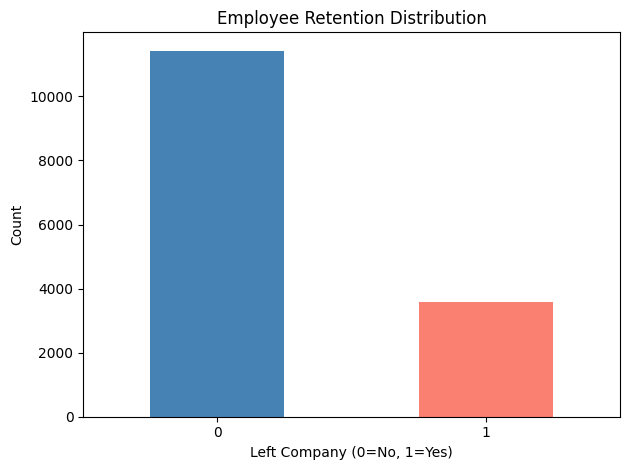

In [4]:
# Target variable distribution
print('Employee Left (0=Stayed, 1=Left):')
print(df['left'].value_counts())

df['left'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Employee Retention Distribution')
plt.xlabel('Left Company (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

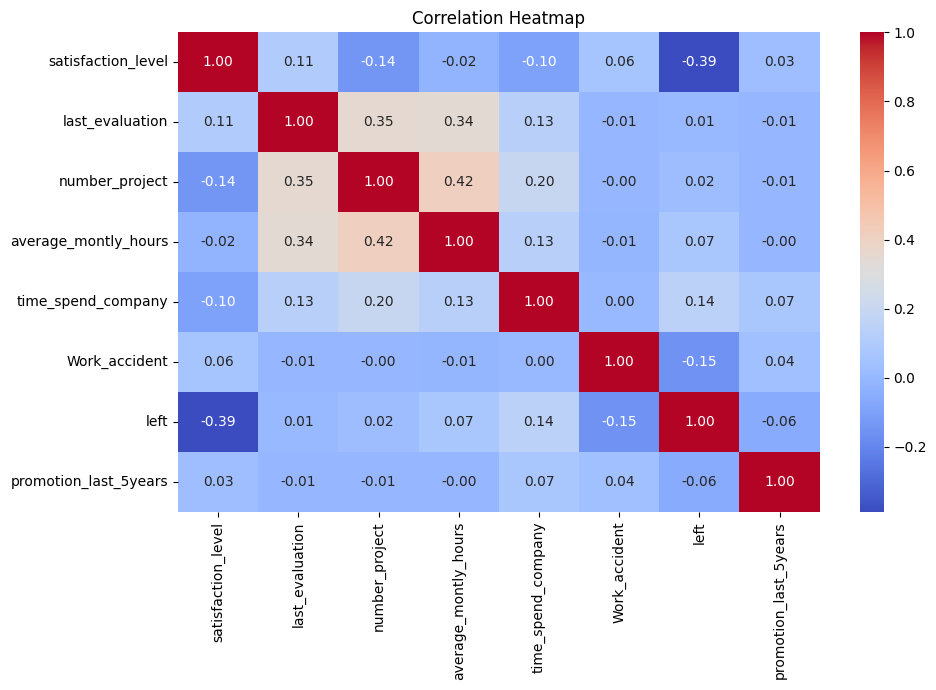

In [5]:
# Correlation Heatmap (numeric features)
plt.figure(figsize=(10, 7))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

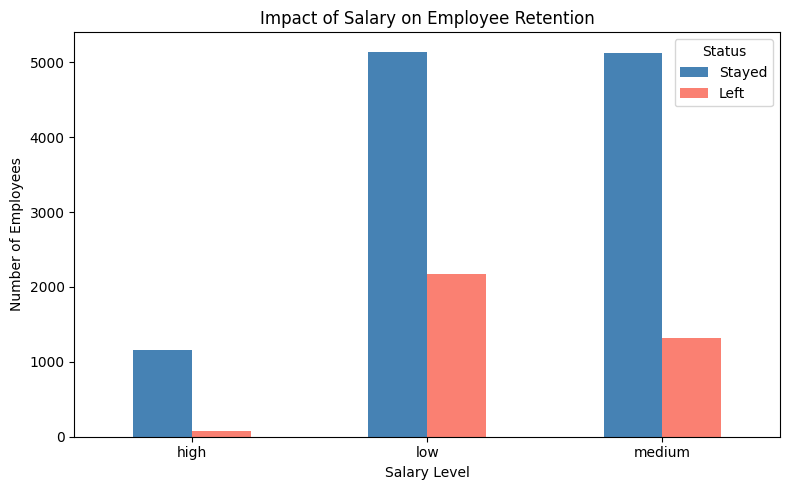

In [6]:
# Bar Chart: Salary vs Employee Retention
salary_retention = df.groupby(['salary', 'left']).size().unstack()
salary_retention.columns = ['Stayed', 'Left']

salary_retention.plot(kind='bar', figsize=(8, 5), color=['steelblue', 'salmon'])
plt.title('Impact of Salary on Employee Retention')
plt.xlabel('Salary Level')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

In [ ]:
# Bar Chart: Department vs Employee Retention
dept_retention = df.groupby(['Department', 'left']).size().unstack()
dept_retention.columns = ['Stayed', 'Left']

dept_retention.plot(kind='bar', figsize=(12, 5), color=['steelblue', 'salmon'])
plt.title('Correlation Between Department and Employee Retention')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

In [ ]:
# Encode categorical variables
le = LabelEncoder()
df['salary_enc'] = le.fit_transform(df['salary'])        # low=1, medium=2, high=0
df['Department_enc'] = le.fit_transform(df['Department'])

# Select features based on EDA (variables with clear impact)
# High correlation: satisfaction_level, number_project, average_monthly_hours, time_spend_company, Work_accident, promotion_last_5years, salary
features = ['satisfaction_level', 'last_evaluation', 'number_project',
            'average_montly_hours', 'time_spend_company', 'Work_accident',
            'promotion_last_5years', 'salary_enc']

X = df[features]
y = df['left']

print('Features selected:', features)
print('X shape:', X.shape)
print('y shape:', y.shape)

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build Logistic Regression Model
model_binary = LogisticRegression(max_iter=1000, random_state=42)
model_binary.fit(X_train_scaled, y_train)

print('Model trained successfully!')

In [ ]:
# Predictions & Accuracy
y_pred_binary = model_binary.predict(X_test_scaled)
accuracy_binary = accuracy_score(y_test, y_pred_binary)

print(f'Accuracy of Binary Logistic Regression Model: {accuracy_binary * 100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_binary, target_names=['Stayed', 'Left']))

In [ ]:
# Confusion Matrix
cm_binary = confusion_matrix(y_test, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_binary, display_labels=['Stayed', 'Left'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Binary Classification (HR Dataset)')
plt.tight_layout()
plt.show()

In [ ]:
# Load Zoo Dataset
zoo_df = pd.read_csv('zoo-data.csv')
class_df = pd.read_csv('zoo-class_type.csv')

print('Zoo Data Shape:', zoo_df.shape)
print('Class Type Data Shape:', class_df.shape)
zoo_df.head()

In [ ]:
# Basic Info
print('Zoo Dataset Info:')
print(zoo_df.info())
print('\nMissing Values:')
print(zoo_df.isnull().sum())
print('\nClass Type Distribution:')
print(zoo_df['class_type'].value_counts())

In [ ]:
# Drop non-feature columns (animal_name is just an identifier)
if 'animal_name' in zoo_df.columns:
    zoo_df = zoo_df.drop(columns=['animal_name'])

# Separate features and target
X_zoo = zoo_df.drop(columns=['class_type'])
y_zoo = zoo_df['class_type']

print('Features shape:', X_zoo.shape)
print('Target shape:', y_zoo.shape)
print('\nClass distribution:')
print(y_zoo.value_counts().sort_index())

In [ ]:
# Train-Test Split
X_zoo_train, X_zoo_test, y_zoo_train, y_zoo_test = train_test_split(
    X_zoo, y_zoo, test_size=0.2, random_state=42, stratify=y_zoo
)

# Feature Scaling
scaler_zoo = StandardScaler()
X_zoo_train_scaled = scaler_zoo.fit_transform(X_zoo_train)
X_zoo_test_scaled = scaler_zoo.transform(X_zoo_test)

# Build Logistic Regression Model (multi_class='multinomial' for softmax)
model_multi = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
model_multi.fit(X_zoo_train_scaled, y_zoo_train)

print('Multiclass Logistic Regression Model trained successfully!')

In [ ]:
# Predictions & Accuracy
y_zoo_pred = model_multi.predict(X_zoo_test_scaled)
accuracy_multi = accuracy_score(y_zoo_test, y_zoo_pred)

print(f'Accuracy of Multiclass Logistic Regression Model: {accuracy_multi * 100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_zoo_test, y_zoo_pred))

In [ ]:
# Confusion Matrix for Multiclass
cm_multi = confusion_matrix(y_zoo_test, y_zoo_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_zoo.unique()),
            yticklabels=sorted(y_zoo.unique()))
plt.title('Confusion Matrix - Multiclass Classification (Zoo Dataset)')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()